# Benchmark Analysis

This notebook uses the benchmark analysis API from `examples/benchmark_runner.py` to:

1. load a full benchmark session
2. group runs by restart family and select the top `K` groups by minimal `best_loss`
3. plot aggregate loss lines for the selected subset
4. load the best model from each selected restart group and scatter plot samples


In [2]:
from pathlib import Path
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np

from benchmark_runner import (
    entries_to_frame,
    entry_arrays,
    get_lines,
    import_runtime_dependencies,
    load_entry_model,
    load_experiment_entries,
    restart_group_columns,
)


In [3]:
entries = []

# ``Baseline fairness`` for KL/ST problem (c.f. reviewer #2)
# big sweep of anderson, additional runs for SGD and Adam with different LR
# session_dir = Path('./results/kl_st/benchmark_20260728_211822/')

# session_dir = Path('./results/kl_st/benchmark_20260729_235818/')


# Additional runs of Adam and SGD with 1M+ iterations
# session_dir = Path('./results/kl_st_small_lr/benchmark_20260729_155018/')
# entries += load_experiment_entries(session_dir)
# session_dir = Path('./results/mnist_anderson/benchmark_20260728_015458/')
# session_dir = Path('./results/ce_two_spirals_anderson_big/benchmark_20260715_173225/')
# session_dir = Path('./results/ce_checkerboard_big/benchmark_20260716_011405/')
# session_dir = Path('./results/mmd_8gaussians_big/benchmark_20260717_002534/')

# clipping gradient, not update vector; anderson
#session_dir = Path('./results/ce_two_spirals_anderson/benchmark_20260715_143611/')
#session_dir_adaptive = Path('./results/ce_two_spirals_anderson_adaptive/benchmark_20260715_154313/')
# clipping gradient, not update vector; smaller clipping
#session_dir_ngd = Path('./results/ce_two_spirals_arch_search_clipping/benchmark_20260713_232123/')
# clipping gradient, not update vector; larger clipping
# session_dir = Path('./results/ce_two_spirals_arch_search_clipping/benchmark_20260713_144235/')

session_dir = Path('./results/mnist_anderson_multi_history/benchmark_20260801_143528/')

entries += load_experiment_entries(session_dir)
for e in entries:
    e['method_kwargs'].pop('max_iterations')
    e['method_kwargs'].pop('eval_every')

for entry in entries:
    if 'bw_multipliers' in entry['problem']['functional']:
        entry['problem']['functional']['bw_multipliers'] = tuple(entry['problem']['functional']['bw_multipliers'])

df_all = entries_to_frame(entries)

In [48]:
def select_top_k_restart_groups(entries, k):
    frame = entries_to_frame(entries) 
    # frame = frame.query("method in [ 'sgd', 'adam'] and `method_kwargs.learning_rate` <= 1e-6 ")
    frame = frame.query(
         "(method in ['anderson', 'ngd'] "
         " and `method_kwargs.linear_solver_regularization` == 5e-3"
         # " and `method_kwargs.regularization_factor` in [0.1, @np.nan]"
         #" and `method_kwargs.step_size` in [0.01]"
         " and `method_kwargs.history_length` in [2, @np.nan]"
         " or "
         "(method in ['adam'])"
         ")")
    # frame = frame.query(
    #     "`method_kwargs.step_size` == 0.01"
    #     " and `method_kwargs.natural_grad_clipping_threshold` == 0.5"
    #     " and ("
    #     "    ("
    #     "     `method` == 'anderson'"
    #     "     and `method_kwargs.regularization_method` == 'adaptive'"
#   #       "     and `method_kwargs.relaxation` == 5.0"
    #     "     and `method_kwargs.regularization_factor` == 1e-4"
    #     "    )"
    #     "     or "
    #     "    (`method` == 'ngd')"
    #     ")"
    # )

    # frame = frame.query("`method_kwargs.linear_solver_regularization` >= 0.01 and `method_kwargs.step_size` == 0.01 and `method_kwargs.natural_grad_clipping_threshold` == .1")
    # frame = frame.query("`method_kwargs.natural_grad_clipping_threshold` <= 10.0 and `method_kwargs.linear_solver_regularization` >= 0.001")
    # frame = frame.query(
    #     "`architecture.rhs.dim_hidden` == 64"
    #     " and `method_kwargs.natural_grad_clipping_threshold` == .5 "
    #     " and `method_kwargs.linear_solver_regularization` >= 0.001" )
    # frame = frame.query('`architecture.rhs.n_hidden` == 1 and `architecture.rhs.dim_hidden` == 16 and best_loss > best_loss.quantile(0.02)')
    group_cols = restart_group_columns(frame)

    if not group_cols:
        summary = frame[['entry_index', 'best_loss']].copy()
        summary['group_rank'] = 0
        return entries, summary

    summary = (
        frame.groupby(group_cols, sort=False, dropna=False, as_index=False)
        .agg(
            final_loss=('best_iteration', 'min'),
            n_restarts=('entry_index', 'count'),
        )
        .sort_values('final_loss', ascending=True, kind='stable')
        .head(k)
        # .reset_index(drop=True)
    )
    summary['group_rank'] = np.arange(len(summary))

    selected_frame = frame.merge(summary[group_cols], on=group_cols, how='inner')
    selected_indices = selected_frame['entry_index'].tolist()
    subset_entries = [entries[index] for index in selected_indices]
    return subset_entries, summary


def best_entry_per_restart_group(entries):
    frame = entries_to_frame(entries)
    group_cols = restart_group_columns(frame)

    if not group_cols:
        if not entries:
            return []
        best_index = int(frame['best_loss'].idxmin())
        return [entries[int(frame.loc[best_index, 'entry_index'])]]

    best_row_indices = (
        frame.groupby(group_cols, sort=False, dropna=False)['best_loss']
        .idxmin()
        .tolist()
    )
    entry_indices = frame.loc[best_row_indices, 'entry_index'].tolist()
    return [entries[int(index)] for index in entry_indices]


In [49]:
top_k = 100
subset_entries, subset_summary = select_top_k_restart_groups(entries, top_k)
best_entries = best_entry_per_restart_group(subset_entries)

print(f'selected {len(subset_entries)} entries across {len(best_entries)} restart groups')



selected 7 entries across 7 restart groups


In [58]:
method_to_zorder = {'sgd':  0, 'adam': 6, 'anderson': 2, 'ngd':5 }
def label_to_zorder(label):
    for m in method_to_zorder:
        if f"method {m}" in label:
            return method_to_zorder[m]
    return 0
    
label_full_to_short = {'method ': '', 
                       'regularization_method ': '', 
                       'regularization_factor': r'$\lambda =$', 
                       'linear_solver_regularization': r"$\Lambda =$",
                       'history_length': '$m =$',
                       'learning_rate': 'lr'}


def plot_line_groups(groups, loss_cutoff=None):
    nc = 1
    for group in groups:
        fig, ax = plt.subplots(figsize=(9, 5), layout='constrained')

        for line in group['lines']:
            style = line.get('style', {})
            color = style.get('color')
            linestyle = style.get('linestyle', '-')
            linewidth = style.get('linewidth', 1.5)

            if 'loss_mean' in line:
                loss_mean = np.asarray(line['loss_mean'], dtype=float)
                loss_mean = np.convolve(loss_mean, np.ones(nc)/nc)
                x = np.arange(len(loss_mean))
                ax.plot(
                    x,
                    loss_mean,
                    label=line['label'],
                    color=color,
                    linestyle=linestyle,
                    linewidth=linewidth,
                )
            else:
                loss = np.asarray(line['loss'], dtype=float)
                if loss_cutoff is not None:
                    loss[~np.isfinite(loss)] = np.inf
                    if np.all(loss > loss_cutoff):
                       continue
                    idx_best = np.argmin(loss > loss_cutoff)
                    loss = loss[:idx_best]
        
                loss = np.convolve(loss, np.ones(nc)/nc)
                x = np.arange(len(loss))
                linewidth = 3. if 'ngd' in line['label'] else linewidth
                linewidth = 3. if 'adam' in line['label'] else linewidth
                label = line['label']
                for key in label_full_to_short:
                    label = label.replace(key, label_full_to_short[key], 1)
                ax.plot(
                    x,
                    loss,
                    label=label,
                    color=color,
                    linestyle=linestyle,
                    linewidth=linewidth,
                    alpha=0.8,
                    zorder = label_to_zorder(line['label'])
                )

        ax.set_title(group['title'])
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Loss')
        # ax.set_xlim(left=0, right=10)
        ax.set_ylim(top=40., bottom=-80)
        # ax.set_yscale('log')
        ax.grid()
        # fig.legend(loc='outside center right')
        
        fig.legend(loc='outside lower center', ncols=4)
        return fig


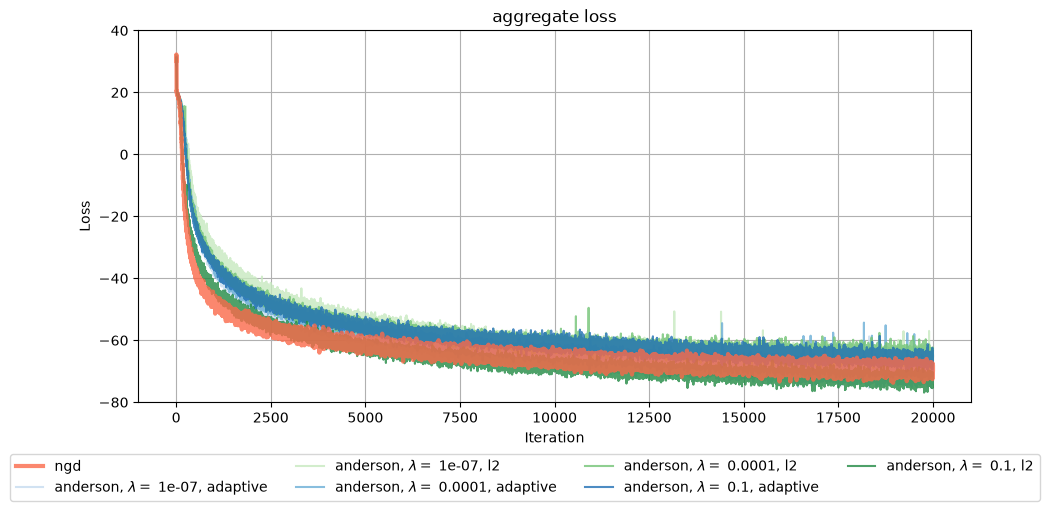

In [59]:
style_channels = {
    'colormap': ['Reds', 'Blues', 'Greens', 'Purples', 'Greys',],
    'linestyle': ['-', '--', ':', '-.'],
}
param_to_channel = {
    'method': 'cmap',
    'history_length': 'cmap',
    'learning_rate': 'color',
    'regularization_factor': 'color',
    'relaxation': 'color',
    'regularization_method': 'cmap' }

groups = get_lines(subset_entries, style_channels=style_channels, style_channel_map=param_to_channel)
fig = plot_line_groups(groups, )
fig.savefig(f"convergence.pdf")
plt.show()

In [44]:
def scatter_best_entries(entries, checkpoint_key='best', n_samples=512):
    if not entries:
        return

    deps = import_runtime_dependencies()
    ncols = min(3, len(entries))
    nrows = int(np.ceil(len(entries) / ncols))
    fig, axs = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 4 * nrows),
        layout='constrained',
    )
    axs = np.atleast_1d(axs).ravel()

    for ax, entry in zip(axs, entries, strict=False):
        model = load_entry_model(entry, key=checkpoint_key)
        samples = model.sample(n_samples, deps['nnx'].Rngs(0))

        if samples.shape[-1] >= 2:
            ax.scatter(samples[:, 0], samples[:, 1], s=6, alpha=0.7)
            ax.set_xlabel('x[0]')
            ax.set_ylabel('x[1]')
        else:
            ax.hist(samples[:, 0], bins=40)

        ax.set_title(
            # f"{entry['run_id']} {entry['method']}\n"
            f"{entry['run_id']} {entry['method']} lr{entry['method_kwargs'].get('learning_rate', 100):.1e}\n"
            f"best_loss={entry.get('best_loss', np.nan):.3e}, iter={entry.get('best_iteration')}"
        )
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        ax.grid()

    for ax in axs[len(entries):]:
        ax.axis('off')

    return fig


In [23]:
bes = sorted(entries, key=lambda e: e['best_iteration'] if e['method'] == 'anderson' and e['method_kwargs'].get('relaxation', 100) == 1.0 else np.inf)[:14]

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/Home/optimier/aksenov/miniconda3/envs/neuripp/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 495, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/Home/optimier/aksenov/miniconda3/envs/neuripp/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 370, in initialize
    _check_cuda_versions(raise_on_first_error = True)
  File "/Home/optimier/aksenov/miniconda3/envs/neuripp/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:135: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


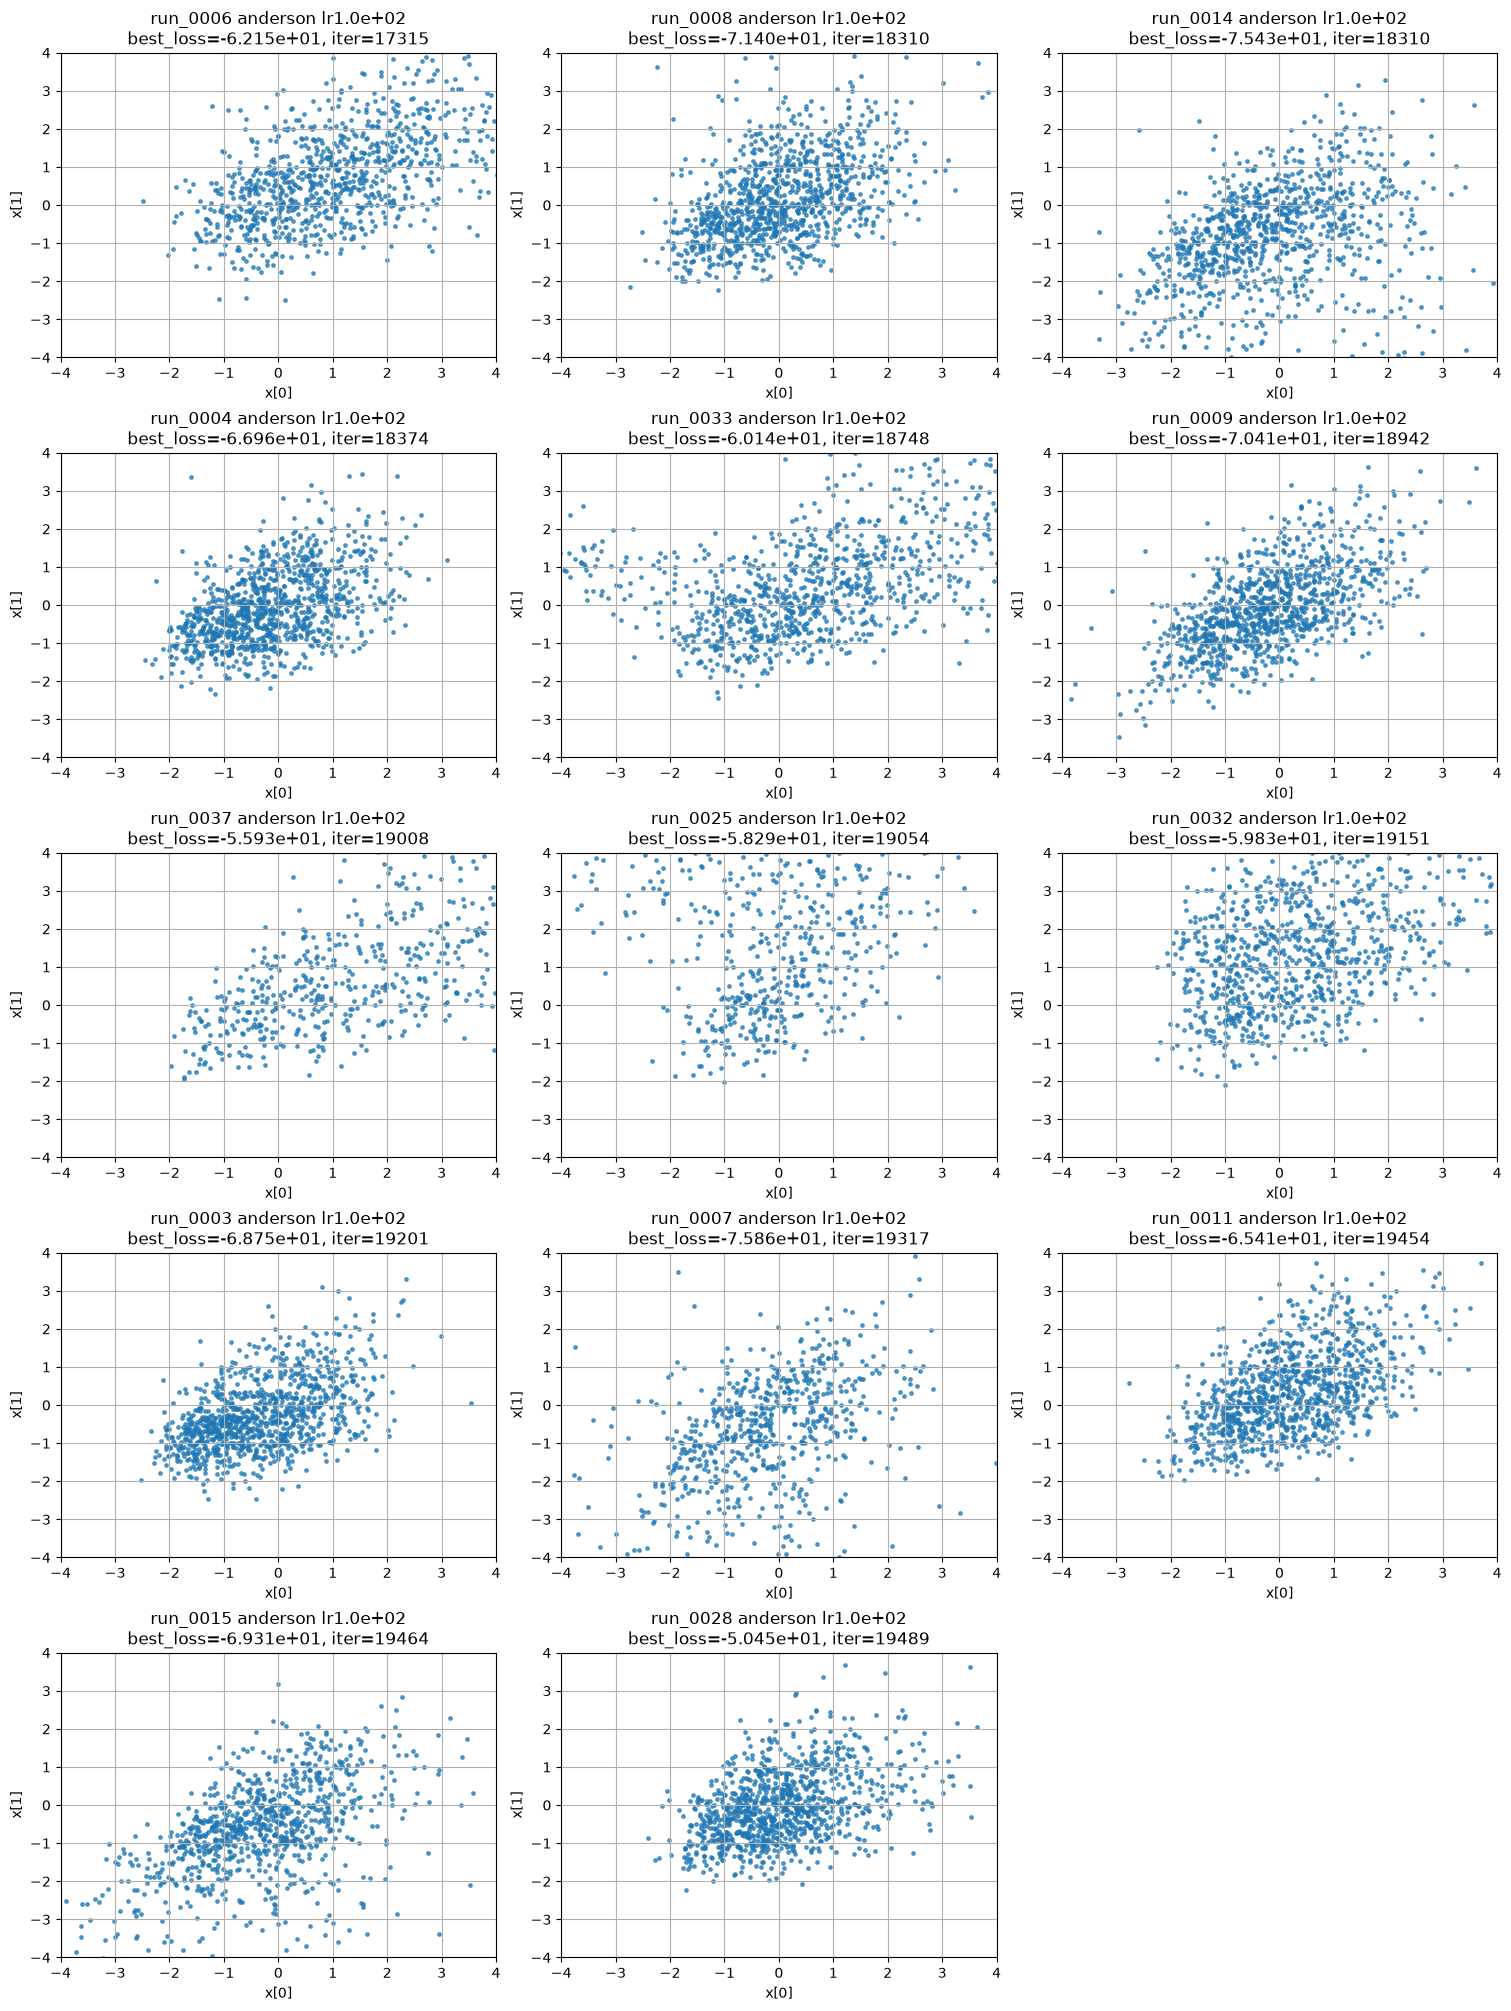

In [24]:
fig = scatter_best_entries(bes, checkpoint_key='best', n_samples=1024)
plt.show()
# fig.savefig("best_scatters.pdf")

In [ ]:
data = np.load(df_adaptive.loc[0, 'run_dir']/'arrays.npz')

In [ ]:
l = data['loss']

In [ ]:
plt.plot(l)

In [ ]:
np.argmin(l)

In [ ]:
l1 = l.copy()
l1[~np.isfinite(l)] = np.inf
np.argmin(l1)

In [ ]:
l[1070:1079]

In [ ]:
np.argmin(np.isfinite(l))

In [ ]:
5. > np.nan

In [ ]:
np.nan < np.nan

In [ ]:
df_adaptive['best_loss']